# ECDC Surveillance Atlas of Infectious Diseases

This notebook demonstrates how to access epidemiological data from the **ECDC Surveillance Atlas** — 59 diseases across 31 EU/EEA countries.

**Categories:** vaccine-preventable, food/waterborne, STIs, healthcare-associated, vector-borne, respiratory, zoonotic, and other.

**Requirements:**
```bash
pip install pandas matplotlib seaborn epidatasets
```

## 1. Setup

In [1]:
import warnings
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
print(f"OK. {datetime.now().strftime('%Y-%m-%d %H:%M')}")

OK. 2026-06-22 16:21


## 2. Initialize

In [2]:
from epidatasets.sources.ecdc_atlas import ECDCAtlasAccessor
atlas = ECDCAtlasAccessor()
print(f"{atlas.source_name} — {atlas.source_description[:80]}...")
display(atlas.get_disease_categories())

ecdc_atlas — ECDC Surveillance Atlas of Infectious Diseases — comprehensive spatiotemporal da...


,category,disease_count
0,food_waterborne,11
1,healthcare_associated,3
2,other,5
3,respiratory,6
4,sti,5
5,vaccine_preventable,14
6,vector_borne,7
7,zoonotic,8


## 3. Vaccine-Preventable Diseases

Measles and pertussis across the EU.

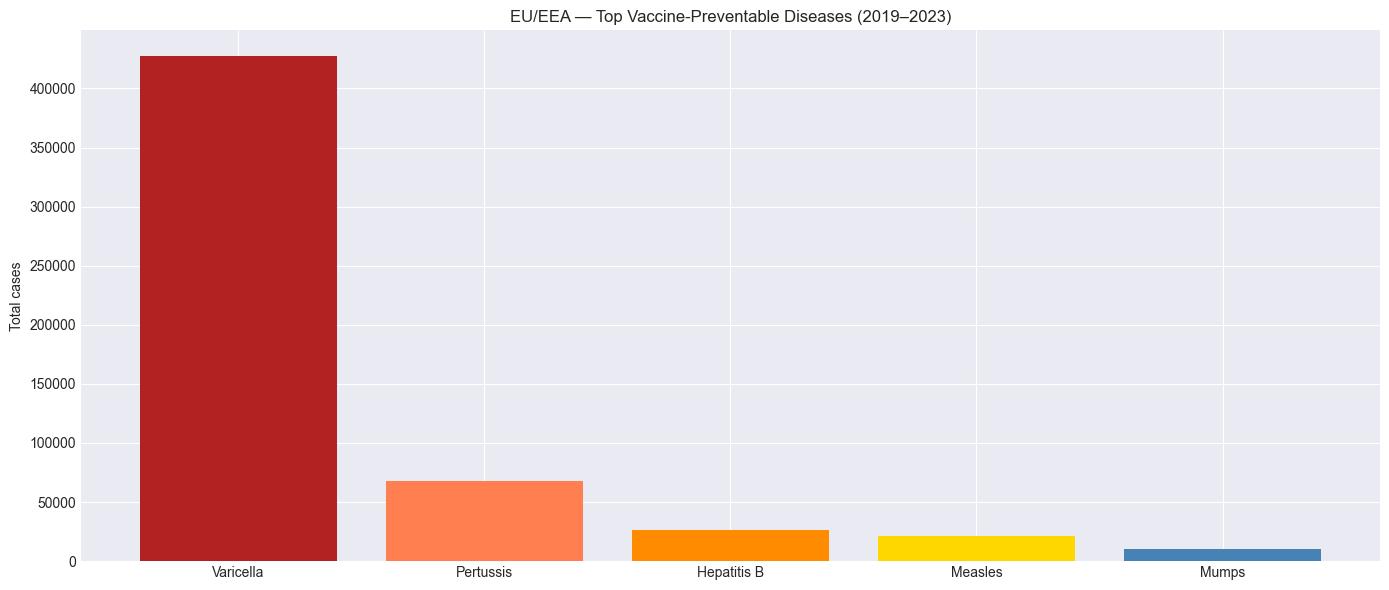

In [3]:
vacc = atlas.get_disease_by_category('vaccine_preventable', years=range(2019, 2024))
summary = vacc.groupby('disease', as_index=False)['cases'].sum()
top = summary.nlargest(5, 'cases')
fig, ax = plt.subplots()
ax.bar(top['disease'], top['cases'], color=['firebrick','coral','darkorange','gold','steelblue'])
ax.set_title('EU/EEA — Top Vaccine-Preventable Diseases (2019–2023)')
ax.set_ylabel('Total cases')
plt.tight_layout()
plt.show()

## 4. Food & Waterborne Diseases

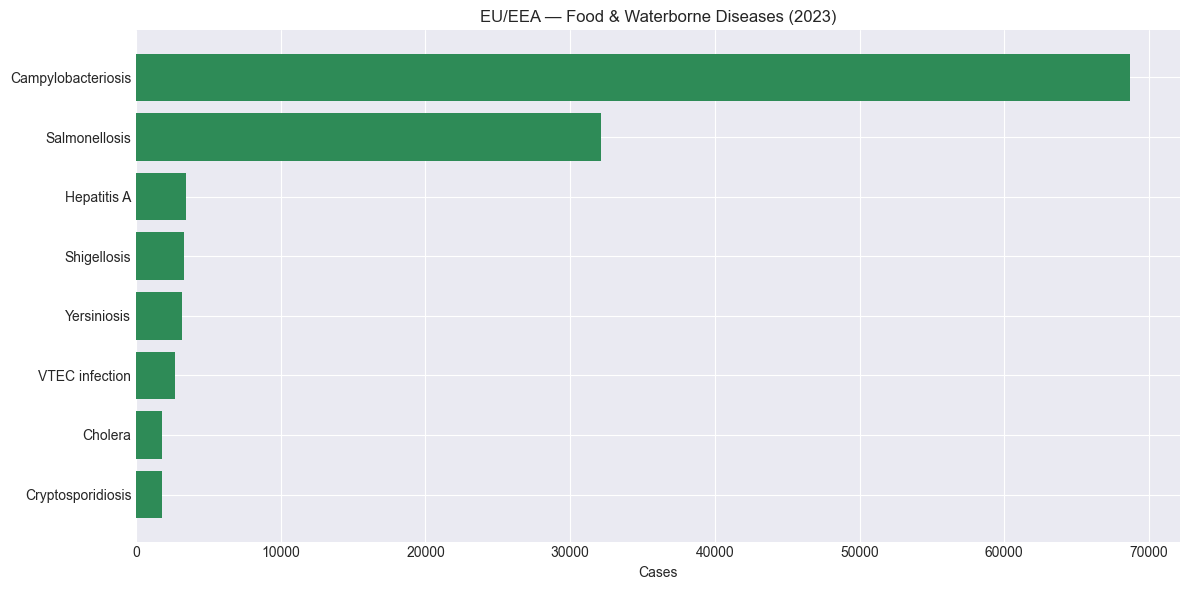

In [4]:
food = atlas.get_disease_by_category('food_waterborne', years=[2023])
food_sum = food.groupby('disease', as_index=False)['cases'].sum()
fig, ax = plt.subplots(figsize=(12, 6))
top = food_sum.nlargest(8, 'cases')
ax.barh(top['disease'][::-1], top['cases'][::-1], color='seagreen')
ax.set_title('EU/EEA — Food & Waterborne Diseases (2023)')
ax.set_xlabel('Cases')
plt.tight_layout()
plt.show()

## 5. Antimicrobial Resistance

E. coli resistance by antibiotic across countries.

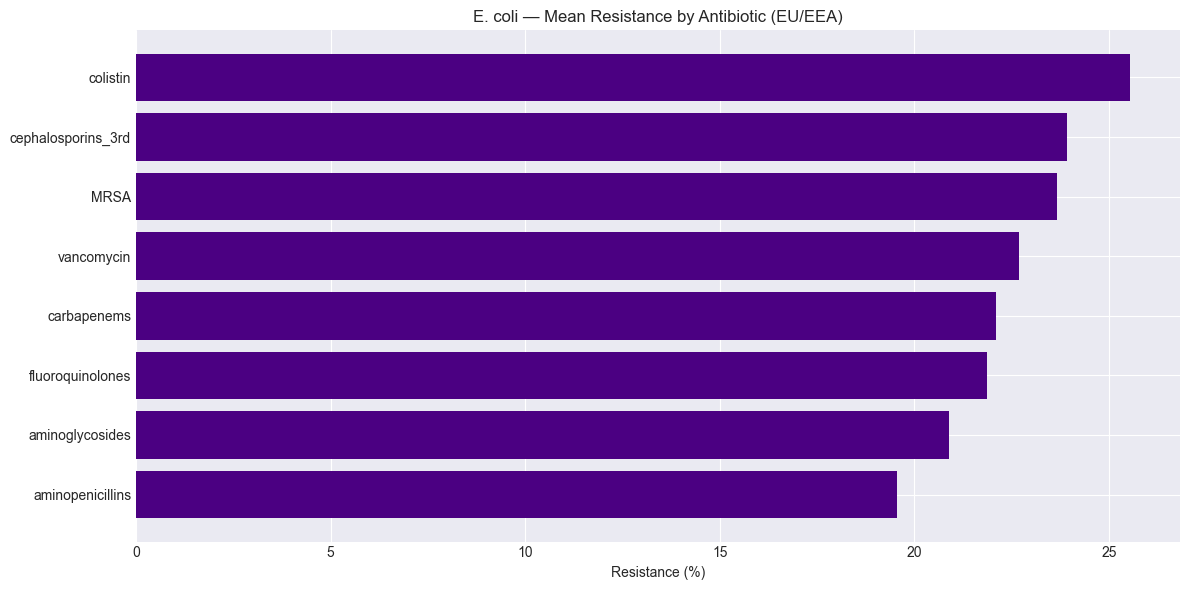

In [5]:
amr = atlas.get_amr_data(pathogen='E. coli')
amr_sum = amr.groupby('antibiotic', as_index=False)['resistance_pct'].mean()
fig, ax = plt.subplots(figsize=(12, 6))
amr_sum = amr_sum.sort_values('resistance_pct')
ax.barh(amr_sum['antibiotic'], amr_sum['resistance_pct'], color='indigo')
ax.set_title('E. coli — Mean Resistance by Antibiotic (EU/EEA)')
ax.set_xlabel('Resistance (%)')
plt.tight_layout()
plt.show()

## 6. Summary

| Method | Description |
|--------|-------------|
| `get_available_diseases()` | 59 diseases with categories |
| `get_disease_data(disease, years)` | Country-level surveillance |
| `get_disease_by_category(cat)` | All diseases in a category |
| `get_amr_data(pathogen, antibiotic)` | Resistance surveillance |
| `get_spatial_data(disease, year)` | Geo-located incidence |
| `get_summary_statistics(year)` | Cross-disease aggregation |

**Related:** [ECDC Open Data](04_ecdc_european_surveillance.ipynb)